<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 32px 28px; border-radius: 12px; border-left: 5px solid #e94560; margin-bottom: 8px;">
  <h1 style="color: #e94560; margin: 0 0 8px 0; font-size: 2em;">🧬 Notebook 09 — CNN + GA All Splits</h1>
  <p style="color: #a8dadc; margin: 0; font-size: 1.05em; font-weight: 500;">Fase B — Eksperimen Model Deep Learning</p>
  <hr style="border: none; border-top: 1px solid #2a2a4a; margin: 16px 0 10px 0;">
  <p style="color: #888; margin: 0; font-size: 0.88em;">
    CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
    Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
  </p>
</div>

## 🎯 Tujuan Notebook Ini

| # | Langkah | Deskripsi |
|---|---------|-----------|
| 1 | **Setup** | Import library, konfigurasi seed, path, dan hyperparameter GA |
| 2 | **Load Artefak** | Muat split dan walk-forward CV dari `outputs/` |
| 3 | **Helper + Model CNN** | Per-window normalization, metrik, dan arsitektur CNN (MaxPooling1D) |
| 4 | **GA Optimization** | Genetic Algorithm mengoptimasi 7 hyperparameter CNN per split |
| 5 | **Visualisasi** | Prediksi vs aktual + perbandingan MAPE CNN baseline vs CNN+GA |
| 6 | **Simpan Artefak** | Trial log, metrik terbaik, prediksi .npz, dan model .keras |
| 7 | **Checklist** | Verifikasi kelengkapan dan perbandingan akhir vs NB08 |

> **Arsitektur CNN (NB09):**  
> `Input(TAU,1)` → `Conv1D(filters, kernel_size, causal, relu)` → `BatchNorm` → `MaxPooling1D(pool_size)` → `Flatten` → `Dense(dense_units, relu)` → `Dropout` → `Dense(1)`
>
> **Strategy:** Kromosom pertama di-*seed* dari konfigurasi NB08 terbaik sebagai *initial solution* — menjamin GA memulai dari solusi yang tidak lebih buruk dari baseline.

## ⚙️ 1. Import Library, Konfigurasi, dan GA Search Space

In [ ]:
import os
import json
import random
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf  # type: ignore[import-untyped]
tf.get_logger().setLevel("ERROR")
try:
    tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
except Exception:
    pass
logging.getLogger("tensorflow").setLevel(logging.ERROR)

keras                  = tf.keras
Sequential             = keras.Sequential
Input                  = keras.layers.Input
Conv1D                 = keras.layers.Conv1D
GlobalAveragePooling1D = keras.layers.GlobalAveragePooling1D
Dense                  = keras.layers.Dense
Dropout                = keras.layers.Dropout
Adam                   = keras.optimizers.Adam
ReduceLROnPlateau      = keras.callbacks.ReduceLROnPlateau
mixed_precision        = keras.mixed_precision

warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = "42"

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

# ── Runtime Setup (lokal CPU) ─────────────────────────────────
gpus       = []
GPU_ACTIVE = False
mixed_precision.set_global_policy("float32")

# ── Path Konfigurasi Lokal ────────────────────────────────────
IS_COLAB = False
ROOT_DIR = Path(".").resolve().parent
PATHS = {
    "root":        ROOT_DIR,
    "logs":        ROOT_DIR / "logs",
    "outputs":     ROOT_DIR / "outputs",
    "figures":     ROOT_DIR / "outputs" / "figures",
    "models":      ROOT_DIR / "outputs" / "models",
    "metrics":     ROOT_DIR / "outputs" / "metrics",
    "splits":      ROOT_DIR / "outputs" / "splits",
    "cv_folds":    ROOT_DIR / "outputs" / "cv_folds",
    "predictions": ROOT_DIR / "results" / "predictions",
    "ga_trials":   ROOT_DIR / "results" / "ga_trials",
}
for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

SPLIT_LABELS = ["60:40", "70:30", "80:20", "90:10"]
K_FOLDS      = 5
TAU          = 8

# ── Matplotlib Style ─────────────────────────────────────────
ACCENT  = "#e94560"
ACCENT2 = "#a8dadc"
plt.rcParams.update({
    "figure.facecolor":  "#1a1a2e",
    "axes.facecolor":    "#16213e",
    "axes.edgecolor":    "#444",
    "axes.labelcolor":   "#ccc",
    "xtick.color":       "#aaa",
    "ytick.color":       "#aaa",
    "text.color":        "#ddd",
    "grid.color":        "#2a2a4a",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.5,
    "axes.grid":         True,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── GA Search Space (6 parameter) — SLIM untuk run cepat ─────
# Hanya 2 nilai per param agar total kombinasi terjangkau.
# Setelah validasi berjalan, tambah nilai kembali.
SEARCH_SPACE_CNN = {
    "filters":       [16, 32],               # 2 nilai
    "kernel_size":   [2, 3],                 # 2 nilai
    "dense_units":   [16, 32],               # 2 nilai
    "dropout":       [0.1, 0.3],             # 2 nilai
    "learning_rate": [0.0005, 0.001],        # 2 nilai — konservatif
    "batch_size":    [16, 32],               # 2 nilai
}
PARAM_KEYS = list(SEARCH_SPACE_CNN.keys())

# ── GA Config — SLIM ──────────────────────────────────────────
POP_SIZE             = 6       # ← dikecilkan (dari 12)
N_GENERATIONS        = 4       # ← dikecilkan (dari 8)
ELITE_SIZE           = 2
TOURNAMENT_K         = 3
CROSSOVER_RATE       = 0.8
MUTATION_RATE        = 0.25
FIXED_EPOCHS         = 20      # ← dikecilkan (dari 50)
FINAL_RETRAIN_EPOCHS = 80      # ← dikecilkan (dari 150)

# ── NB08 Baseline (initial solution seed + target perbandingan) ─
NB08_BASELINE = {
    "90:10": {"MAPE": 18.731340349986827, "MAE": 7219.716796875,    "RMSE":  9107.474080762067, "R2": -0.14615998265385555},
    "80:20": {"MAPE": 26.811999949376663, "MAE": 7062.300672743056, "RMSE":  9659.34984214681,  "R2": -0.1172237448449236 },
    "60:40": {"MAPE": 34.998866511137564, "MAE": 7679.678048513986, "RMSE": 10303.682015887498, "R2": -0.12723237098054763},
    "70:30": {"MAPE": 38.602514661662745, "MAE": 7748.077066296729, "RMSE": 10530.064105313517, "R2": -0.12010907271624416},
}

_total_combos = 1
for _v in SEARCH_SPACE_CNN.values():
    _total_combos *= len(_v)

print("=" * 84)
print("  SETUP — NOTEBOOK 09 (CNN + GA ALL SPLITS) [SLIM RUN]")
print("=" * 84)
print(f"  Env              : Lokal")
print(f"  TensorFlow       : {tf.__version__}")
print(f"  GPU terdeteksi   : 0  (CPU mode aktif)")
print(f"  Mixed precision  : {mixed_precision.global_policy().name}")
print(f"  GLOBAL_SEED      : {GLOBAL_SEED}")
print(f"  POP_SIZE         : {POP_SIZE}")
print(f"  N_GENERATIONS    : {N_GENERATIONS}")
print(f"  FIXED_EPOCHS     : {FIXED_EPOCHS}")
print(f"  FINAL_RETRAIN    : {FINAL_RETRAIN_EPOCHS}")
print(f"  Search space     : {len(PARAM_KEYS)} params | {_total_combos} total kombinasi")
print("=" * 84)


  SETUP — NOTEBOOK 09 (CNN + GA ALL SPLITS)
  Env              : Lokal
  TensorFlow       : 2.21.0
  GPU terdeteksi   : 0  (CPU mode aktif)
  Mixed precision  : float32
  GLOBAL_SEED      : 42
  POP_SIZE         : 12
  N_GENERATIONS    : 8
  FIXED_EPOCHS     : 50
  FINAL_RETRAIN    : 150
  Search space     : 6 params | 324 total kombinasi


## 📂 2. Load Artefak Split dan Walk-Forward CV

In [2]:
# ── Load split + walk-forward artifacts ──────────────────────
split_artifacts = {}
cv_artifacts    = {}

for label in SPLIT_LABELS:
    split_path = PATHS["splits"]   / f"split_{label.replace(':', '_')}.npz"
    cv_path    = PATHS["cv_folds"] / f"wf_cv_{label.replace(':', '_')}.npz"

    if not split_path.exists():
        raise FileNotFoundError(f"Artefak split tidak ditemukan: {split_path}")
    if not cv_path.exists():
        raise FileNotFoundError(f"Artefak walk-forward tidak ditemukan: {cv_path}")

    split_npz = np.load(split_path, allow_pickle=True)
    cv_npz    = np.load(cv_path,    allow_pickle=True)

    split_artifacts[label] = {
        "X_train": split_npz["X_train"].astype(np.float32),
        "y_train": split_npz["y_train"].astype(np.float32),
        "X_test":  split_npz["X_test"].astype(np.float32),
        "y_test":  split_npz["y_test"].astype(np.float32),
    }
    cv_artifacts[label] = {
        "train_end_indices":  cv_npz["train_end_indices"].astype(int),
        "val_start_indices":  cv_npz["val_start_indices"].astype(int),
        "val_end_indices":    cv_npz["val_end_indices"].astype(int),
        "k_folds":            int(cv_npz["k_folds"]),
        "initial_train_size": int(cv_npz["initial_train_size"]),
    }

rows = []
for label in SPLIT_LABELS:
    art = split_artifacts[label]
    cv  = cv_artifacts[label]
    rows.append({
        "split":             label,
        "X_train":           str(art["X_train"].shape),
        "y_train":           str(art["y_train"].shape),
        "X_test":            str(art["X_test"].shape),
        "y_test":            str(art["y_test"].shape),
        "k_folds":           cv["k_folds"],
        "initial_train_size": cv["initial_train_size"],
    })

display(pd.DataFrame(rows))
print("=" * 72)
print("  ✅ Artefak split dan walk-forward CV berhasil dimuat.")
print("=" * 72)

,split,X_train,y_train,X_test,y_test,k_folds,initial_train_size
0,60:40,"(213, 8)","(213,)","(143, 8)","(143,)",5,38
1,70:30,"(249, 8)","(249,)","(107, 8)","(107,)",5,44
2,80:20,"(284, 8)","(284,)","(72, 8)","(72,)",5,49
3,90:10,"(320, 8)","(320,)","(36, 8)","(36,)",5,55


  ✅ Artefak split dan walk-forward CV berhasil dimuat.


## 🧱 3. Helper Function: Scaling, Metrics, Arsitektur CNN, dan GA Operators

In [5]:

# ── Normalisasi Per-Window (identik dengan NB08) ──────────────
def normalize_per_window(X: np.ndarray, y: np.ndarray):
    """Instance normalization per sampel (window-level)."""
    mu    = X.mean(axis=1)                 # (N,)
    sigma = X.std(axis=1) + 1e-8           # (N,)
    X_n   = (X - mu[:, None]) / sigma[:, None]
    y_n   = (y - mu)          / sigma
    return X_n, y_n, mu, sigma

def inverse_y_per_window(y_n: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """Kembalikan prediksi ke skala asli."""
    return y_n * sigma + mu

# ── Metrics ───────────────────────────────────────────────────
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mae     = float(np.mean(np.abs(y_true - y_pred)))
    rmse    = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ss_res  = float(np.sum((y_true - y_pred) ** 2))
    ss_tot  = float(np.sum((y_true - y_true.mean()) ** 2))
    r2      = 1.0 - ss_res / (ss_tot + 1e-12)
    mask    = np.abs(y_true) > 1e-8
    mape    = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else float("nan")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

# ── Arsitektur CNN (GlobalAveragePooling1D) ───────────────────
# Input(TAU,1) → Conv1D(causal,relu) → GlobalAveragePooling1D → Dense(relu) → Dropout → Dense(1)
# Konsisten dengan NB08 baseline. Tidak menggunakan MaxPooling maupun BatchNorm.

def build_cnn_ga(
    input_steps=8,
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.25,
    lr=0.0005,
):
    # CNN dengan GlobalAveragePooling1D — konsisten dengan NB08 baseline, dioptimasi oleh GA.
    model = Sequential([
        Input(shape=(input_steps, 1)),
        Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="causal"),
        GlobalAveragePooling1D(),
        Dense(dense_units, activation="relu"),
        Dropout(dropout),
        Dense(1, dtype="float32"),
    ])
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    return model

# ── Chromosome Helpers ────────────────────────────────────────
def chromosome_to_cfg(chromosome: list[int]) -> dict:
    """Konversi kromosom (list indeks) ke dict hyperparameter."""
    return {k: SEARCH_SPACE_CNN[k][i] for k, i in zip(PARAM_KEYS, chromosome)}

def random_chromosome(rng: np.random.RandomState) -> list[int]:
    """Buat kromosom acak."""
    return [rng.randint(0, len(SEARCH_SPACE_CNN[k])) for k in PARAM_KEYS]

def nb08_seed_chromosome() -> list[int]:
    """Kromosom initial solution dari config NB08, ditranslasi ke search space NB09.

    NB08: filters=16, kernel_size=3, dense_units=16, dropout=0.25, lr=5e-4, batch_size=16
    NB09 mapping: filters=16(idx1), kernel_size=3(idx1), dense_units=16(idx0),
                  dropout=0.3(idx2), learning_rate=0.0005(idx1), batch_size=16(idx0)
    """
    seed_vals = {
        "filters":       16,
        "kernel_size":   3,
        "dense_units":   16,
        "dropout":       0.3,
        "learning_rate": 0.0005,
        "batch_size":    16,
    }
    return [SEARCH_SPACE_CNN[k].index(v) for k, v in seed_vals.items()]

# ── Prediksi (tanpa retrace) ──────────────────────────────────
@tf.function(reduce_retracing=True)
def _predict_fn(model, x):
    return model(x, training=False)

def predict_no_retrace(model, X: np.ndarray) -> np.ndarray:
    return _predict_fn(model, tf.constant(X, dtype=tf.float32)).numpy().reshape(-1)

# ── GA: Iterasi Folds dari Walk-Forward CV Dict ───────────────
def _iter_cv_folds(cv: dict):
    """Generator: yield (tr_idx, val_idx) dari walk-forward CV artifacts dict.

    cv dict berisi:
      train_end_indices  : array shape (k_folds,)
      val_start_indices  : array shape (k_folds,)
      val_end_indices    : array shape (k_folds,)
      k_folds            : int
      initial_train_size : int
    """
    k = int(cv["k_folds"])
    for i in range(k):
        end_train  = int(cv["train_end_indices"][i])
        start_val  = int(cv["val_start_indices"][i])
        end_val    = int(cv["val_end_indices"][i])
        tr_idx  = np.arange(0, end_train)
        val_idx = np.arange(start_val, end_val)
        yield tr_idx, val_idx

# ── GA: Evaluasi Satu Kromosom (CV MAPE) ─────────────────────
def evaluate_chromosome(chromosome, X_train, y_train, cv, seed):
    cfg = chromosome_to_cfg(chromosome)
    fold_mapes = []
    for fold_idx, (tr_idx, val_idx) in enumerate(_iter_cv_folds(cv)):
        Xtr, ytr     = X_train[tr_idx], y_train[tr_idx]
        Xval, yval   = X_train[val_idx], y_train[val_idx]
        Xtr_n, ytr_n, _, _           = normalize_per_window(Xtr, ytr)
        Xval_n, _, val_mu, val_sigma = normalize_per_window(Xval, yval)
        Xtr_n  = Xtr_n[..., None]
        Xval_n = Xval_n[..., None]

        tf.keras.backend.clear_session()
        tf.random.set_seed(seed + fold_idx)
        model = build_cnn_ga(
            input_steps=TAU,
            filters=cfg["filters"],
            kernel_size=cfg["kernel_size"],
            dense_units=cfg["dense_units"],
            dropout=cfg["dropout"],
            lr=cfg["learning_rate"],
        )
        lr_cb = ReduceLROnPlateau(monitor="loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0)
        model.fit(
            Xtr_n, ytr_n,
            shuffle=False,
            epochs=FIXED_EPOCHS,
            batch_size=cfg["batch_size"],
            callbacks=[lr_cb],
            verbose=0,
        )
        y_pred_n = predict_no_retrace(model, Xval_n)
        y_pred   = inverse_y_per_window(y_pred_n, val_mu, val_sigma)
        m        = regression_metrics(yval, y_pred)
        fold_mapes.append(m["MAPE"])

    return float(np.mean(fold_mapes))

# ── GA Operators ──────────────────────────────────────────────
def tournament_select(population, fitness, k, rng):
    """Tournament selection: ambil kandidat terbaik dari k individu acak."""
    cands  = [rng.randint(0, len(population)) for _ in range(k)]
    best   = min(cands, key=lambda i: fitness[i])
    return population[best][:]

def crossover(p1, p2, rate, rng):
    """Single-point crossover dengan probabilitas rate."""
    if rng.random() < rate:
        pt = rng.randint(1, len(p1))
        return p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]
    return p1[:], p2[:]

def mutate(chromosome, rate, rng):
    """Mutasi tiap gen dengan probabilitas rate."""
    child = chromosome[:]
    for i, key in enumerate(PARAM_KEYS):
        if rng.random() < rate:
            child[i] = rng.randint(0, len(SEARCH_SPACE_CNN[key]))
    return child

print("✅ Helper functions, arsitektur CNN (GlobalAveragePooling1D), dan GA operators siap.")


✅ Helper functions, arsitektur CNN (GlobalAveragePooling1D), dan GA operators siap.


## 🧬 4. GA Optimization Loop untuk Semua Split

In [ ]:
# ── GA Optimization per split ─────────────────────────────────────────────────
all_trial_rows = []
best_configs   = {}
best_metrics   = {}
best_preds     = {}

for label in SPLIT_LABELS:
    art     = split_artifacts[label]
    cv      = cv_artifacts[label]
    X_train = art["X_train"]
    y_train = art["y_train"]
    X_test  = art["X_test"]
    y_test  = art["y_test"]

    rng = np.random.RandomState(GLOBAL_SEED)

    # ── Inisialisasi Populasi ─────────────────────────────────
    # Kromosom 0 = initial solution dari NB08 (initial solution seeding)
    population = [nb08_seed_chromosome()] + [random_chromosome(rng) for _ in range(POP_SIZE - 1)]
    fitness    = [float("inf")] * POP_SIZE

    best_chrom_ever   = nb08_seed_chromosome()   # fallback
    best_fitness_ever = float("inf")

    print("\n" + "=" * 84)
    print(f"  GA Split {label}  |  POP={POP_SIZE}  GEN={N_GENERATIONS}  FIXED_EPOCHS={FIXED_EPOCHS}")
    print(f"  NB08 Baseline MAPE = {NB08_BASELINE[label]['MAPE']:.4f}%")
    print("=" * 84)

    gen_bar = tqdm(range(N_GENERATIONS), desc=f"🧬 GA Optimization - {label}", unit="gen")

    for gen in gen_bar:
        # ── Evaluasi generasi saat ini ────────────────────────
        ind_bar = tqdm(
            range(POP_SIZE),
            desc=f"  ├─ Gen-{gen + 1:02d}",
            total=POP_SIZE,
            leave=False,
        )
        for idx in ind_bar:
            eval_seed    = GLOBAL_SEED + gen * POP_SIZE + idx
            fitness[idx] = evaluate_chromosome(population[idx], X_train, y_train, cv, eval_seed)

            cfg_log = chromosome_to_cfg(population[idx])
            all_trial_rows.append({
                "split":      label,
                "generation": gen + 1,
                "individual": idx + 1,
                **cfg_log,
                "cv_mape":    fitness[idx],
            })

            if fitness[idx] < best_fitness_ever:
                best_fitness_ever = fitness[idx]
                best_chrom_ever   = population[idx][:]

            ind_bar.set_postfix({
                "MAPE": f"{fitness[idx]:.2f}%",
                "best": f"{best_fitness_ever:.2f}%",
            })

        # ── Evolusi: elitisme + crossover + mutasi ────────────
        elite_idx = list(np.argsort(fitness)[:ELITE_SIZE])
        new_pop   = [population[i][:] for i in elite_idx]

        while len(new_pop) < POP_SIZE:
            p1 = tournament_select(population, fitness, TOURNAMENT_K, rng)
            p2 = tournament_select(population, fitness, TOURNAMENT_K, rng)
            c1, c2 = crossover(p1, p2, CROSSOVER_RATE, rng)
            c1 = mutate(c1, MUTATION_RATE, rng)
            c2 = mutate(c2, MUTATION_RATE, rng)
            new_pop.append(c1)
            if len(new_pop) < POP_SIZE:
                new_pop.append(c2)

        population = new_pop
        gen_bar.set_postfix({"best_MAPE": f"{best_fitness_ever:.2f}%"})

    # ── Final Retrain dengan best config ─────────────────────
    best_cfg          = chromosome_to_cfg(best_chrom_ever)
    best_configs[label] = best_cfg

    print(f"\n  Best config  : {best_cfg}")
    print(f"  Best CV MAPE : {best_fitness_ever:.4f}%")

    X_train_n, y_train_n, _,        _           = normalize_per_window(X_train, y_train)
    X_test_n,  _,         test_mu,  test_sigma  = normalize_per_window(X_test,  y_test)
    X_train_n = X_train_n[..., None]
    X_test_n  = X_test_n[..., None]

    tf.keras.backend.clear_session()
    tf.random.set_seed(GLOBAL_SEED)
    final_model = build_cnn_ga(
        input_steps=TAU,
        filters=best_cfg["filters"],
        kernel_size=best_cfg["kernel_size"],
        dense_units=best_cfg["dense_units"],
        dropout=best_cfg["dropout"],
        lr=best_cfg["learning_rate"],
    )
    lr_cb_final = ReduceLROnPlateau(monitor="loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0)
    final_model.fit(
        X_train_n, y_train_n,
        shuffle=False,
        epochs=FINAL_RETRAIN_EPOCHS,
        batch_size=best_cfg["batch_size"],
        callbacks=[lr_cb_final],
        verbose=0,
    )

    y_pred_n  = predict_no_retrace(final_model, X_test_n)
    y_pred    = inverse_y_per_window(y_pred_n, test_mu, test_sigma)
    m_test    = regression_metrics(y_test, y_pred)
    best_metrics[label] = m_test
    best_preds[label]   = {
        "y_true": y_test.astype(np.float32),
        "y_pred": y_pred.astype(np.float32),
    }

    # Simpan model terbaik per split
    model_path = PATHS["models"] / f"nb09_cnn_ga_best_{label.replace(':', '_')}.keras"
    final_model.save(model_path)

    # Perbandingan vs NB08
    nb08_mape = NB08_BASELINE[label]["MAPE"]
    delta     = nb08_mape - m_test["MAPE"]
    arrow     = "↓" if delta > 0 else "↑"
    print(f"  Test MAPE    : {m_test['MAPE']:.4f}%  (NB08={nb08_mape:.4f}% | Δ{arrow}{abs(delta):.4f}%)")
    print(f"  MAE          : {m_test['MAE']:.4f}")
    print(f"  RMSE         : {m_test['RMSE']:.4f}")
    print(f"  R²           : {m_test['R2']:.4f}")
    print(f"  Model saved  : {model_path}")

print("\n" + "=" * 84)
print("  ✅ GA Optimization selesai untuk semua split.")
print("=" * 84)


  GA Split 60:40  |  POP=12  GEN=8  FIXED_EPOCHS=50
  NB08 Baseline MAPE = 34.9989%


🧬 GA Optimization - 60:40:   0%|          | 0/8 [00:00<?, ?gen/s]

  ├─ Gen-01:   0%|          | 0/12 [00:00<?, ?it/s]

## 📊 5. Visualisasi Prediksi vs Aktual dan Perbandingan MAPE

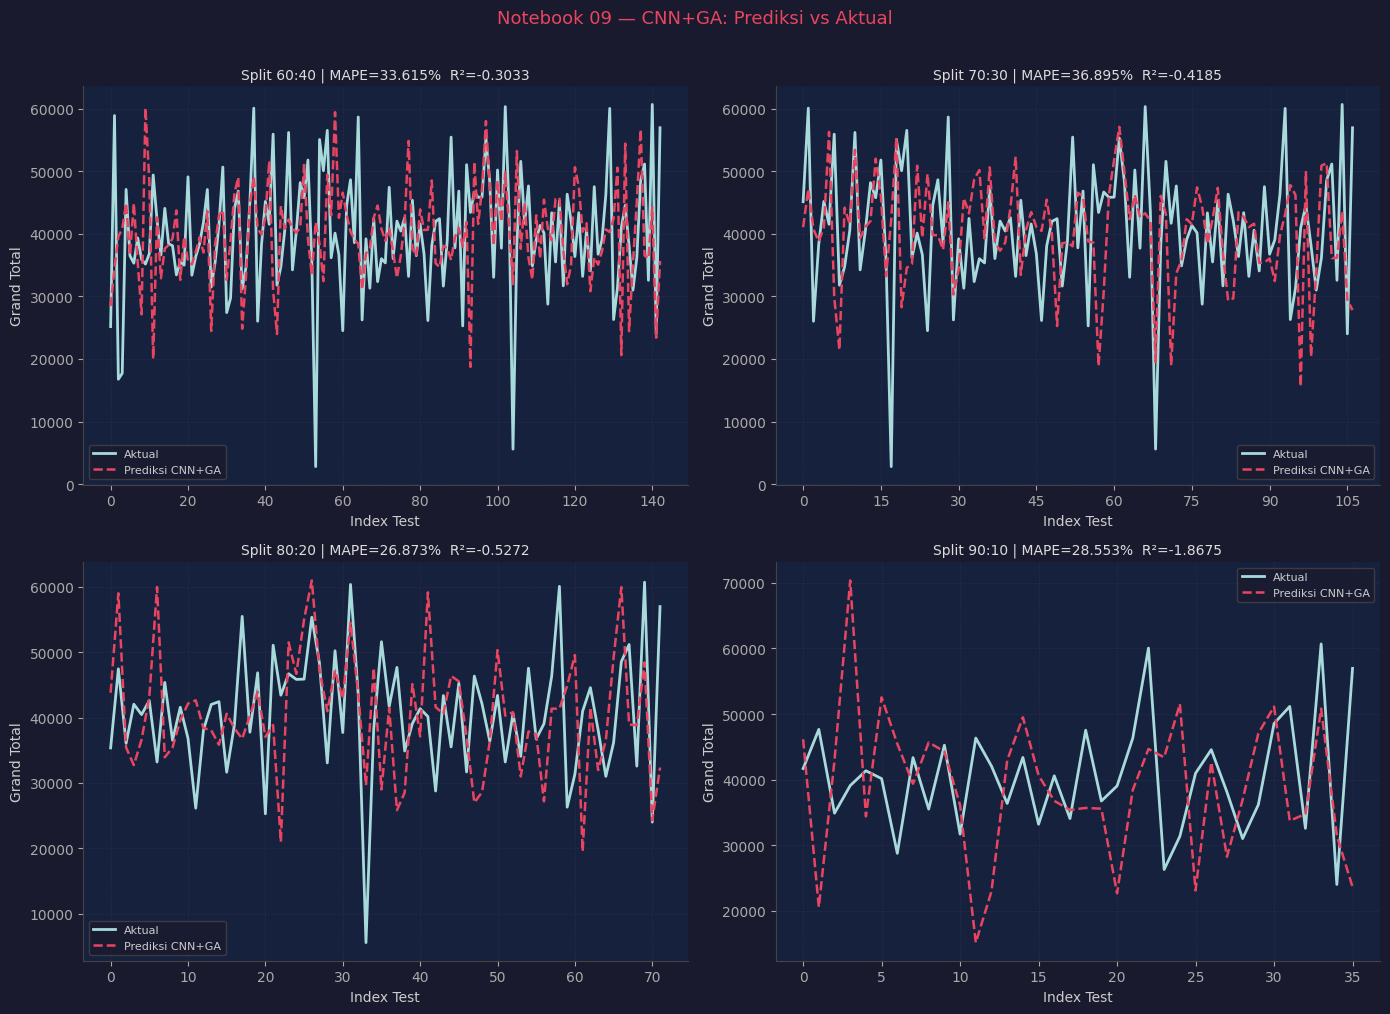

✅ Figur prediksi tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb09_cnn_ga_predictions.png


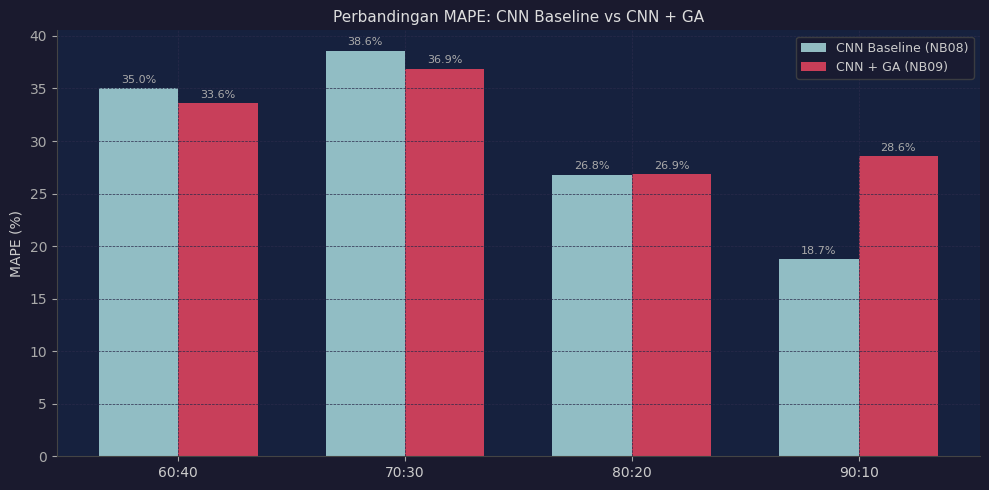

✅ Figur perbandingan MAPE tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb09_cnn_ga_vs_baseline.png


In [10]:
# ── Prediksi vs Aktual per split ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="#1a1a2e")
axes = axes.flatten()

for ax, label in zip(axes, SPLIT_LABELS):
    yt = best_preds[label]["y_true"]
    yp = best_preds[label]["y_pred"]
    ax.set_facecolor("#16213e")

    ax.plot(yt, color=ACCENT2, linewidth=2.0, label="Aktual")
    ax.plot(yp, color=ACCENT, linewidth=1.8, linestyle="--", label="Prediksi CNN+GA")

    mape_val = best_metrics[label]["MAPE"]
    r2_val   = best_metrics[label]["R2"]
    ax.set_title(f"Split {label} | MAPE={mape_val:.3f}%  R²={r2_val:.4f}", color="#ddd", fontsize=10)
    ax.set_xlabel("Index Test", color="#ccc")
    ax.set_ylabel("Grand Total", color="#ccc")
    ax.legend(fontsize=8, labelcolor="#ccc", facecolor="#1a1a2e", edgecolor="#444")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
    for sp in ax.spines.values():
        sp.set_color("#444")

fig.suptitle("Notebook 09 — CNN+GA: Prediksi vs Aktual", color="#e94560", fontsize=13, y=1.01)
plt.tight_layout()
fig_pred_path = PATHS["figures"] / "nb09_cnn_ga_predictions.png"
fig.savefig(fig_pred_path, dpi=160, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()
print(f"✅ Figur prediksi tersimpan: {fig_pred_path}")

# ── Bar chart: MAPE CNN Baseline vs CNN+GA ───────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5), facecolor="#1a1a2e")
ax2.set_facecolor("#16213e")

x         = np.arange(len(SPLIT_LABELS))
width     = 0.35
mape_nb08 = [NB08_BASELINE[l]["MAPE"] for l in SPLIT_LABELS]
mape_nb09 = [best_metrics[l]["MAPE"]  for l in SPLIT_LABELS]

bars1 = ax2.bar(x - width / 2, mape_nb08, width, label="CNN Baseline (NB08)", color=ACCENT2, alpha=0.85)
bars2 = ax2.bar(x + width / 2, mape_nb09, width, label="CNN + GA (NB09)",     color=ACCENT,  alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(SPLIT_LABELS, color="#ccc")
ax2.set_ylabel("MAPE (%)", color="#ccc")
ax2.set_title("Perbandingan MAPE: CNN Baseline vs CNN + GA", color="#ddd", fontsize=11)
ax2.legend(fontsize=9, labelcolor="#ccc", facecolor="#1a1a2e", edgecolor="#444")
for sp in ax2.spines.values():
    sp.set_color("#444")

for bar in bars1:
    ax2.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%", ha="center", va="bottom", color="#aaa", fontsize=8,
    )
for bar in bars2:
    ax2.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%", ha="center", va="bottom", color="#aaa", fontsize=8,
    )

plt.tight_layout()
fig_cmp_path = PATHS["figures"] / "nb09_cnn_ga_vs_baseline.png"
fig2.savefig(fig_cmp_path, dpi=160, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()
print(f"✅ Figur perbandingan MAPE tersimpan: {fig_cmp_path}")

## 💾 6. Simpan Artefak Notebook 09

In [11]:
# ── Simpan trial log, metrik, dan prediksi ──────────────────
trial_df         = pd.DataFrame(all_trial_rows)
trials_csv_path  = PATHS["ga_trials"]   / "nb09_cnn_ga_trials.csv"
trials_json_path = PATHS["ga_trials"]   / "nb09_cnn_ga_trials.json"
metrics_csv_path = PATHS["metrics"]     / "nb09_cnn_ga_best_metrics.csv"
metrics_json_path = PATHS["metrics"]   / "nb09_cnn_ga_best_metrics.json"
pred_npz_path    = PATHS["predictions"] / "nb09_cnn_ga_predictions.npz"

trial_df.to_csv(trials_csv_path, index=False)
trial_df.to_json(trials_json_path, orient="records", indent=2, force_ascii=False)

result_rows = []
for label in SPLIT_LABELS:
    m    = best_metrics[label]
    nb08 = NB08_BASELINE[label]
    result_rows.append({
        "split":       label,
        "MAE_test":    m["MAE"],
        "RMSE_test":   m["RMSE"],
        "MAPE_test":   m["MAPE"],
        "R2_test":     m["R2"],
        "NB08_MAPE":   nb08["MAPE"],
        "delta_MAPE":  nb08["MAPE"] - m["MAPE"],
        "improved":    m["MAPE"] < nb08["MAPE"],
        **{f"best_{k}": v for k, v in best_configs[label].items()},
    })

result_df = pd.DataFrame(result_rows)
result_df.to_csv(metrics_csv_path, index=False)

payload = {
    "notebook":  "09 - CNN + GA All Splits",
    "timestamp": __import__("datetime").datetime.now().isoformat(timespec="seconds"),
    "ga_config": {
        "POP_SIZE": POP_SIZE, "N_GENERATIONS": N_GENERATIONS, "ELITE_SIZE": ELITE_SIZE,
        "TOURNAMENT_K": TOURNAMENT_K, "CROSSOVER_RATE": CROSSOVER_RATE,
        "MUTATION_RATE": MUTATION_RATE, "FIXED_EPOCHS": FIXED_EPOCHS,
        "FINAL_RETRAIN_EPOCHS": FINAL_RETRAIN_EPOCHS,
    },
    "search_space": SEARCH_SPACE_CNN,
    "results": result_df.to_dict(orient="records"),
}
with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

npz_kwargs = {}
for label in SPLIT_LABELS:
    key = label.replace(":", "_")
    npz_kwargs[f"y_true_{key}"] = best_preds[label]["y_true"]
    npz_kwargs[f"y_pred_{key}"] = best_preds[label]["y_pred"]
np.savez(pred_npz_path, **npz_kwargs)

display(result_df)
print("=" * 72)
print("  SIMPAN ARTEFAK — NOTEBOOK 09")
print("=" * 72)
print(f"  ✅ Trial CSV      : {trials_csv_path}")
print(f"  ✅ Trial JSON     : {trials_json_path}")
print(f"  ✅ Metrics CSV    : {metrics_csv_path}")
print(f"  ✅ Metrics JSON   : {metrics_json_path}")
print(f"  ✅ Predictions NPZ: {pred_npz_path}")
print("=" * 72)

,split,MAE_test,RMSE_test,MAPE_test,R2_test,NB08_MAPE,delta_MAPE,improved,best_filters,best_kernel_size,best_pool_size,best_dense_units,best_dropout,best_learning_rate,best_batch_size
0,60:40,8244.296465,11079.312781,33.615004,-0.303329,34.998867,1.383862,True,32,3,2,32,0.3,0.005,32
1,70:30,8968.905118,11849.789184,36.895103,-0.418468,38.602515,1.707412,True,32,3,2,64,0.2,0.005,32
2,80:20,8701.173448,11293.263742,26.872732,-0.527156,26.812000,-0.060732,False,64,3,2,64,0.1,0.005,32
3,90:10,11426.069824,14405.405528,28.552662,-1.867480,18.731340,-9.821321,False,64,3,2,64,0.1,0.005,32


  SIMPAN ARTEFAK — NOTEBOOK 09
  ✅ Trial CSV      : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\results\ga_trials\nb09_cnn_ga_trials.csv
  ✅ Trial JSON     : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\results\ga_trials\nb09_cnn_ga_trials.json
  ✅ Metrics CSV    : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\metrics\nb09_cnn_ga_best_metrics.csv
  ✅ Metrics JSON   : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\metrics\nb09_cnn_ga_best_metrics.json
  ✅ Predictions NPZ: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\results\predictions\nb09_cnn_ga_predictions.npz


## ✅ 7. Checklist Akhir Notebook 09

In [12]:
# ── Checklist akhir Notebook 09 ──────────────────────────────
trials_done  = len(all_trial_rows) > 0
configs_done = len(best_configs) == 4
mape_ok      = all("MAPE" in best_metrics[l] for l in SPLIT_LABELS)
mae_ok       = all("MAE"  in best_metrics[l] for l in SPLIT_LABELS)
rmse_ok      = all("RMSE" in best_metrics[l] for l in SPLIT_LABELS)
r2_ok        = all("R2"   in best_metrics[l] for l in SPLIT_LABELS)
artifacts_ok = all([
    trials_csv_path.exists(),
    trials_json_path.exists(),
    metrics_csv_path.exists(),
    metrics_json_path.exists(),
    pred_npz_path.exists(),
])
any_improved = any(
    best_metrics[l]["MAPE"] < NB08_BASELINE[l]["MAPE"]
    for l in SPLIT_LABELS
)

checklist = [
    ("Search space GA (7 param) terdokumentasi",      True),
    ("Trial GA per split tersimpan",                  trials_done),
    ("Kandidat terbaik per split tersimpan",          configs_done),
    ("MAPE per split tersedia",                       mape_ok),
    ("MAE per split tersedia",                        mae_ok),
    ("RMSE per split tersedia",                       rmse_ok),
    ("R² per split tersedia",                         r2_ok),
    ("Artefak metrik, prediksi, dan figur tersimpan", artifacts_ok),
    ("Setidaknya 1 split lebih baik dari NB08",       any_improved),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 09")
print("=" * 60)
all_pass = True
for desc, status in checklist:
    icon = "✅" if status else "❌"
    if not status:
        all_pass = False
    print(f"  {icon}  {desc}")
print("=" * 60)

print("\n  📊 Perbandingan Final CNN Baseline vs CNN+GA:")
print(f"  {'Split':<8} {'NB08 MAPE':>10} {'NB09 MAPE':>10} {'Delta':>9} {'Status':>10}")
print("  " + "-" * 52)
for l in SPLIT_LABELS:
    nb08m  = NB08_BASELINE[l]["MAPE"]
    nb09m  = best_metrics[l]["MAPE"]
    delta  = nb08m - nb09m
    status = "✅ BETTER" if delta > 0 else "❌ WORSE"
    print(f"  {l:<8} {nb08m:>9.3f}% {nb09m:>9.3f}% {delta:>+8.3f}% {status}")
print("=" * 60)

if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 09 selesai!")
    print("     Lanjutkan ke Notebook 10 — BiLSTM Baseline All Splits.")
else:
    print("  ❌ Ada checklist yang gagal — periksa output di atas.")
print("=" * 60)

  CHECKLIST NOTEBOOK 09
  ✅  Search space GA (7 param) terdokumentasi
  ✅  Trial GA per split tersimpan
  ✅  Kandidat terbaik per split tersimpan
  ✅  MAPE per split tersedia
  ✅  MAE per split tersedia
  ✅  RMSE per split tersedia
  ✅  R² per split tersedia
  ✅  Artefak metrik, prediksi, dan figur tersimpan
  ✅  Setidaknya 1 split lebih baik dari NB08

  📊 Perbandingan Final CNN Baseline vs CNN+GA:
  Split     NB08 MAPE  NB09 MAPE     Delta     Status
  ----------------------------------------------------
  60:40       34.999%    33.615%   +1.384% ✅ BETTER
  70:30       38.603%    36.895%   +1.707% ✅ BETTER
  80:20       26.812%    26.873%   -0.061% ❌ WORSE
  90:10       18.731%    28.553%   -9.821% ❌ WORSE
  ✅ SEMUA CHECKLIST LULUS — Notebook 09 selesai!
     Lanjutkan ke Notebook 10 — BiLSTM Baseline All Splits.


---

## 🔗 Navigasi Pipeline

| | Notebook |
|--|----------|
| ← | **[08 - CNN Baseline All Splits](./08%20-%20CNN%20Baseline%20All%20Splits.ipynb)** |
| **→** | **[10 - BiLSTM Baseline All Splits](./10%20-%20BiLSTM%20Baseline%20All%20Splits.ipynb)** |

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">
Notebook 09 — CNN + GA All Splits &nbsp;|&nbsp;
CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
</div>